In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/semeval_hin_mono4sep_results'
ZIP_PATH   = '/content/drive/MyDrive/semeval2025_task7_data.zip'

print('Zip present:', os.path.exists(ZIP_PATH))
print()
print('Output dir contents:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(' -', f)

Mounted at /content/drive
Zip present: True

Output dir contents:
 - evaluation_results_hin
 - final_comparison_hin
 - hin_claim_id_to_text.pkl
 - hin_claim_translations.json
 - hin_frozen_embeddings_checkpoint.pt
 - hin_hin_monolingual_pairs_train_dev.csv
 - hin_post_id_to_text.pkl
 - hin_post_translations.json
 - hin_test_claim_id_to_text.pkl
 - hin_test_claim_translations.json
 - hin_test_finetuned_embeddings.pt
 - hin_test_frozen_embeddings.pt
 - hin_test_post_id_to_text.pkl
 - hin_test_post_translations.json
 - lora_best_dev_hin
 - train_examples_hin_hin_v1.pkl
 - training_checkpoint_hin_v1


In [2]:
import subprocess, sys, os
result = subprocess.run([sys.executable, '-c', 'import torch; print(torch.__version__)'],
                         capture_output=True, text=True)
ver = result.stdout.strip()
print(f'Current torch: {ver}')
if '+cpu' in ver or ver == '':
    os.system('pip uninstall -y torch torchvision torchaudio')
    os.system('pip install -q torch==2.1.2+cu118 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118')
    print('✅ Done! Restart runtime and run from Step 2.')
else:
    print('✅ CUDA torch already installed')

os.system('pip uninstall -y bitsandbytes transformers accelerate peft sentence-transformers -q')
os.system('pip install -q bitsandbytes>=0.43.0 transformers>=4.40.0 accelerate>=0.27.0 peft>=0.10.0 '
          '"sentence-transformers>=3.0.0" sentencepiece pandas numpy scikit-learn matplotlib datasets tqdm')

import ast, json, os, zipfile, warnings, time, gc, shutil, re, pickle, tempfile
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import torch
import random
warnings.filterwarnings('ignore')

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y', 'torchao', '-q'])
print('✅ torchao pre-emptively removed.')
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')

Current torch: 2.11.0+cu128
✅ CUDA torch already installed
✅ torchao pre-emptively removed.
PyTorch: 2.11.0+cu128 | CUDA: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_PATH   = '/content/drive/MyDrive/semeval2025_task7_data.zip'
EXTRACT_DIR = '/content/semeval2025'
OUTPUT_DIR  = '/content/drive/MyDrive/semeval_hin_mono4sep_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(EXTRACT_DIR):
    print('Extracting...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
else:
    print('Already extracted')

def find_folder(root, target):
    for dirpath, dirnames, _ in os.walk(root):
        if target in dirnames:
            return os.path.join(dirpath, target)
    return None

TRAIN_DEV_DIR = find_folder(EXTRACT_DIR, 'train_dev_sets')
print(f'TRAIN_DEV_DIR : {TRAIN_DEV_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting...
TRAIN_DEV_DIR : /content/semeval2025/train_dev_sets


In [4]:
def read_csv_safely(path):
    return pd.read_csv(path)

fact_checks_path    = os.path.join(TRAIN_DEV_DIR, 'fact_checks.csv')
posts_path          = os.path.join(TRAIN_DEV_DIR, 'posts.csv')
pairs_path          = os.path.join(TRAIN_DEV_DIR, 'pairs.csv')
pairs_dev_mono_path = os.path.join(TRAIN_DEV_DIR, 'pairs_dev_monolingual.csv')
tasks_path          = os.path.join(TRAIN_DEV_DIR, 'tasks.json')

fact_checks      = read_csv_safely(fact_checks_path)
posts            = read_csv_safely(posts_path)
pairs_train_all  = read_csv_safely(pairs_path)
pairs_dev_mono   = read_csv_safely(pairs_dev_mono_path)

with open(tasks_path, 'r', encoding='utf-8') as f:
    tasks = json.load(f)

print(f'fact_checks : {fact_checks.shape}')
print(f'posts       : {posts.shape}')

fact_checks : (153743, 4)
posts       : (24431, 5)


In [5]:
LANG = 'eng'
eng_task = tasks['monolingual'][LANG]
eng_fact_check_ids  = set(eng_task['fact_checks'])
eng_posts_train_ids = set(eng_task['posts_train'])
eng_posts_dev_ids   = set(eng_task['posts_dev'])

assert len(eng_fact_check_ids) == 85734
assert len(eng_posts_train_ids) == 4351
assert len(eng_posts_dev_ids) == 478
print('✅ eng task ids restored.')

✅ eng task ids restored.


In [6]:
eng_train_pairs = pairs_train_all[
    pairs_train_all['post_id'].isin(eng_posts_train_ids) &
    pairs_train_all['fact_check_id'].isin(eng_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

eng_dev_pairs = pairs_dev_mono[
    pairs_dev_mono['post_id'].isin(eng_posts_dev_ids) &
    pairs_dev_mono['fact_check_id'].isin(eng_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

assert len(eng_train_pairs) == 5446
assert len(eng_dev_pairs)   == 627
print('✅ eng_train_pairs / eng_dev_pairs restored.')

✅ eng_train_pairs / eng_dev_pairs restored.


In [7]:
with open(os.path.join(OUTPUT_DIR, 'hin_claim_id_to_text.pkl'), 'rb') as f:
    hin_claim_id_to_text = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'hin_post_id_to_text.pkl'), 'rb') as f:
    hin_post_id_to_text = pickle.load(f)

_ckpt13 = torch.load(
    os.path.join(OUTPUT_DIR, 'hin_frozen_embeddings_checkpoint.pt'),
    weights_only=False
)
hin_claim_ids = _ckpt13['claim_ids']

hin_usable_train_pairs = eng_train_pairs[
    eng_train_pairs['post_id'].isin(hin_post_id_to_text.keys()) &
    eng_train_pairs['fact_check_id'].isin(hin_claim_id_to_text.keys())
].reset_index(drop=True)

hin_usable_dev_pairs = eng_dev_pairs[
    eng_dev_pairs['post_id'].isin(hin_post_id_to_text.keys()) &
    eng_dev_pairs['fact_check_id'].isin(hin_claim_id_to_text.keys())
].reset_index(drop=True)

print(f'✅ Restored: hin_claim_id_to_text={len(hin_claim_id_to_text)}, hin_post_id_to_text={len(hin_post_id_to_text)}')
print(f'hin_usable_train_pairs={len(hin_usable_train_pairs)}, hin_usable_dev_pairs={len(hin_usable_dev_pairs)}')

✅ Restored: hin_claim_id_to_text=85734, hin_post_id_to_text=4829
hin_usable_train_pairs=5446, hin_usable_dev_pairs=627


In [8]:
TEST_SET_DIR = find_folder(EXTRACT_DIR, 'test_set')
test_fact_checks_path = os.path.join(TEST_SET_DIR, 'fact_checks.csv')
test_posts_path       = os.path.join(TEST_SET_DIR, 'posts.csv')
test_pairs_mono_path  = os.path.join(TEST_SET_DIR, 'pairs_test_monolingual.csv')
test_tasks_path       = os.path.join(TEST_SET_DIR, 'tasks.json')
test_mono_ref_path    = os.path.join(TEST_SET_DIR, 'monolingual_reference.json')

test_fact_checks = read_csv_safely(test_fact_checks_path)
test_posts       = read_csv_safely(test_posts_path)
test_pairs_mono  = read_csv_safely(test_pairs_mono_path)

with open(test_tasks_path, 'r', encoding='utf-8') as f:
    test_tasks = json.load(f)
with open(test_mono_ref_path, 'r', encoding='utf-8') as f:
    monolingual_reference = json.load(f)

print(f'test fact_checks : {test_fact_checks.shape}')
print(f'test posts       : {test_posts.shape}')

test fact_checks : (272447, 4)
test posts       : (8276, 5)


In [9]:
eng_test_task = test_tasks['monolingual'][LANG]
eng_test_fact_check_ids = set(eng_test_task['fact_checks'])
eng_test_posts_ids      = set(eng_test_task['posts_test'])
assert len(eng_test_posts_ids) == 500
assert len(eng_test_fact_check_ids) == 145287

eng_test_pairs = test_pairs_mono[
    test_pairs_mono['post_id'].isin(eng_test_posts_ids) &
    test_pairs_mono['fact_check_id'].isin(eng_test_fact_check_ids)
].drop_duplicates().reset_index(drop=True)

print(f'✅ eng_test_pairs restored: {len(eng_test_pairs)}')

✅ eng_test_pairs restored: 740


In [10]:
with open(os.path.join(OUTPUT_DIR, 'hin_test_claim_id_to_text.pkl'), 'rb') as f:
    hin_test_claim_id_to_text = pickle.load(f)
with open(os.path.join(OUTPUT_DIR, 'hin_test_post_id_to_text.pkl'), 'rb') as f:
    hin_test_post_id_to_text = pickle.load(f)

hin_usable_test_pairs = eng_test_pairs[
    eng_test_pairs['post_id'].isin(hin_test_post_id_to_text.keys()) &
    eng_test_pairs['fact_check_id'].isin(hin_test_claim_id_to_text.keys())
].reset_index(drop=True)

hin_test_claim_ids = list(hin_test_claim_id_to_text.keys())
hin_test_post_ids_list = [pid for pid in eng_test_posts_ids if pid in hin_test_post_id_to_text]
hin_test_post_texts_list = [hin_test_post_id_to_text[pid] for pid in hin_test_post_ids_list]
hin_test_claim_texts = [hin_test_claim_id_to_text[cid] for cid in hin_test_claim_ids]

hin_test_reference = {
    str(pid): [str(fc) for fc in fcs]
    for pid, fcs in monolingual_reference.items()
    if int(pid) in eng_test_posts_ids
}

print(f'✅ Hindi TEST set restored — hin_test_reference={len(hin_test_reference)} (expect 500)')

✅ Hindi TEST set restored — hin_test_reference=500 (expect 500)


In [11]:
def success_at_k(retrieved_ranked, ground_truth, k):
    hits = 0
    N = len(ground_truth)
    for pid, true_fcs in ground_truth.items():
        if pid not in retrieved_ranked:
            continue
        if any(fc in true_fcs for fc in retrieved_ranked[pid][:k]):
            hits += 1
    return hits / N

def evaluate_all_k(retrieved_ranked, ground_truth, ks=(1, 5, 10)):
    results = {}
    for k in ks:
        score = success_at_k(retrieved_ranked, ground_truth, k)
        results[f'success@{k}'] = score
        print(f'success@{k}: {score:.4f}')
    return results
print('Metric functions ready.')

Metric functions ready.


In [12]:
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F

MODEL_NAME = 'intfloat/multilingual-e5-large'
MAX_LEN = 128
device = 'cuda' if torch.cuda.is_available() else 'cpu'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = torch.sum(last_hidden * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts

CKPT_DIR = os.path.join(OUTPUT_DIR, 'training_checkpoint_hin_v1')
print('✅ State fully restored. Proceed to Step 12 (load fine-tuned model).')

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

✅ State fully restored. Proceed to Step 12 (load fine-tuned model).


In [13]:
from peft import PeftModel

FINAL_ADAPTER_PATH = os.path.join(OUTPUT_DIR, 'lora_best_dev_hin')
if not os.path.exists(FINAL_ADAPTER_PATH):
    FINAL_ADAPTER_PATH = os.path.join(CKPT_DIR, 'adapter')
    print(f'⚠️ No dev-selected adapter found — using latest checkpoint: {FINAL_ADAPTER_PATH}')

eval_base_model = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(device)
eval_model = PeftModel.from_pretrained(eval_base_model, FINAL_ADAPTER_PATH)
eval_model.eval()
print(f'✅ Loaded fine-tuned Hindi model from: {FINAL_ADAPTER_PATH}')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅ Loaded fine-tuned Hindi model from: /content/drive/MyDrive/semeval_hin_mono4sep_results/lora_best_dev_hin


In [14]:
# ============================================================
# CELL 32 (REVISED): ENCODE HINDI TEST DATA WITH FINE-TUNED MODEL
# — checkpointed, so if Colab disconnects after this, just reload instead
#   of re-encoding.
# ============================================================
EVAL_ENCODE_BATCH = 32
FT_TEST_EMB_PATH = os.path.join(OUTPUT_DIR, 'hin_test_finetuned_embeddings.pt')

@torch.no_grad()
def encode_texts_eval(texts, prefix, model, batch_size=EVAL_ENCODE_BATCH):
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=f'Encoding ({prefix.strip(": ")})'):
        batch = [prefix + t for t in texts[i:i+batch_size]]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            out = model(**enc)
            emb = mean_pool(out.last_hidden_state, enc['attention_mask'])
            emb = F.normalize(emb, p=2, dim=1)
        all_embs.append(emb.cpu())
        del enc, out, emb
    return torch.cat(all_embs, dim=0)

if os.path.exists(FT_TEST_EMB_PATH):
    ckpt = torch.load(FT_TEST_EMB_PATH)
    hin_test_claim_embs, hin_test_post_embs = ckpt['claim_embs'], ckpt['post_embs']
    print(f'✅ Loaded fine-tuned test embeddings from checkpoint — skipped re-encoding.')
else:
    print(f'Encoding {len(hin_test_claim_texts)} TEST claims and {len(hin_test_post_texts_list)} TEST posts (Hindi)...')
    hin_test_claim_embs = encode_texts_eval(hin_test_claim_texts, prefix='passage: ', model=eval_model)
    hin_test_post_embs  = encode_texts_eval(hin_test_post_texts_list, prefix='query: ', model=eval_model)
    torch.save({'claim_embs': hin_test_claim_embs, 'post_embs': hin_test_post_embs}, FT_TEST_EMB_PATH)
    print(f'💾 Saved to {FT_TEST_EMB_PATH}')

torch.cuda.empty_cache()
print(f'hin_test_claim_embs: {hin_test_claim_embs.shape}, hin_test_post_embs: {hin_test_post_embs.shape}')

✅ Loaded fine-tuned test embeddings from checkpoint — skipped re-encoding.
hin_test_claim_embs: torch.Size([145287, 1024]), hin_test_post_embs: torch.Size([500, 1024])


In [15]:
# ============================================================
# CELL 33: RETRIEVE TOP-10 RANKED CLAIMS PER TEST POST (Hindi, fine-tuned)
# ============================================================
TOP_K_RETRIEVE = 10
QUERY_CHUNK_EVAL = 128

hin_test_claim_embs_gpu = hin_test_claim_embs.to(device).float()
hin_retrieved_ranked = {}

for start in tqdm(range(0, len(hin_test_post_ids_list), QUERY_CHUNK_EVAL), desc='Retrieving top-10 (hi)'):
    chunk_pids = hin_test_post_ids_list[start:start+QUERY_CHUNK_EVAL]
    chunk_embs = hin_test_post_embs[start:start+QUERY_CHUNK_EVAL].to(device).float()
    sims = chunk_embs @ hin_test_claim_embs_gpu.T
    topk_scores, topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1)
    topk_idx = topk_idx.cpu()
    for i, pid in enumerate(chunk_pids):
        hin_retrieved_ranked[str(pid)] = [str(hin_test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_scores, topk_idx

del hin_test_claim_embs_gpu
torch.cuda.empty_cache()
print(f'Retrieved rankings for {len(hin_retrieved_ranked)} posts.')

Retrieving top-10 (hi): 100%|██████████| 4/4 [00:00<00:00, 11.66it/s]

Retrieved rankings for 500 posts.


In [16]:
# ============================================================
# CELL 34: RUN SUCCESS@1, @5, @10 EVALUATION — Hindi fine-tuned
# ============================================================
print('=== Fine-tuned ME5-Large (LoRA, fused text) — Hindi Monolingual Test ===\n')
hin_results_finetuned = evaluate_all_k(hin_retrieved_ranked, hin_test_reference, ks=(1, 5, 10))

=== Fine-tuned ME5-Large (LoRA, fused text) — Hindi Monolingual Test ===

success@1: 0.3660
success@5: 0.6260
success@10: 0.6860


In [17]:
# ============================================================
# CELL 35: SAVE RESULTS TO DRIVE
# ============================================================
hin_eval_output_dir = os.path.join(OUTPUT_DIR, 'evaluation_results_hin')
os.makedirs(hin_eval_output_dir, exist_ok=True)

with open(os.path.join(hin_eval_output_dir, 'success_at_k_hin_mono.json'), 'w') as f:
    json.dump(hin_results_finetuned, f, indent=2)

with open(os.path.join(hin_eval_output_dir, 'predictions_hin_mono.json'), 'w') as f:
    json.dump(hin_retrieved_ranked, f, indent=2)

print(f'Saved to: {hin_eval_output_dir}')
for k, v in hin_results_finetuned.items():
    print(f'  {k}: {v:.4f}')

Saved to: /content/drive/MyDrive/semeval_hin_mono4sep_results/evaluation_results_hin
  success@1: 0.3660
  success@5: 0.6260
  success@10: 0.6860


In [18]:
# ============================================================
# CELL 36 (REVISED): LIVE EVALUATION — FROZEN BASE MODEL (Hindi test set)
# — checkpointed, separate file from Cell 13 (different data: test pool).
# ============================================================
FR_TEST_EMB_PATH = os.path.join(OUTPUT_DIR, 'hin_test_frozen_embeddings.pt')

for _v in ['frozen_model']:
    if _v in globals():
        del globals()[_v]
gc.collect(); torch.cuda.empty_cache()

frozen_model = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float16).to(device)
frozen_model.eval()

if os.path.exists(FR_TEST_EMB_PATH):
    ckpt = torch.load(FR_TEST_EMB_PATH)
    hin_frozen_claim_embs, hin_frozen_post_embs = ckpt['claim_embs'], ckpt['post_embs']
    print('✅ Loaded frozen test embeddings from checkpoint — skipped re-encoding.')
else:
    print('Encoding Hindi TEST claims + posts with FROZEN base model...')
    hin_frozen_claim_embs = encode_texts_eval(hin_test_claim_texts, prefix='passage: ', model=frozen_model)
    hin_frozen_post_embs  = encode_texts_eval(hin_test_post_texts_list, prefix='query: ', model=frozen_model)
    torch.save({'claim_embs': hin_frozen_claim_embs, 'post_embs': hin_frozen_post_embs}, FR_TEST_EMB_PATH)
    print(f'💾 Saved to {FR_TEST_EMB_PATH}')

hin_frozen_claim_embs_gpu = hin_frozen_claim_embs.to(device).float()
hin_frozen_retrieved_ranked = {}

for start in tqdm(range(0, len(hin_test_post_ids_list), QUERY_CHUNK_EVAL), desc='Retrieving (frozen, hi)'):
    chunk_pids = hin_test_post_ids_list[start:start+QUERY_CHUNK_EVAL]
    chunk_embs = hin_frozen_post_embs[start:start+QUERY_CHUNK_EVAL].to(device).float()
    sims = chunk_embs @ hin_frozen_claim_embs_gpu.T
    topk_scores, topk_idx = torch.topk(sims, k=TOP_K_RETRIEVE, dim=1)
    topk_idx = topk_idx.cpu()
    for i, pid in enumerate(chunk_pids):
        hin_frozen_retrieved_ranked[str(pid)] = [str(hin_test_claim_ids[j]) for j in topk_idx[i].tolist()]
    del chunk_embs, sims, topk_scores, topk_idx

del hin_frozen_claim_embs_gpu
torch.cuda.empty_cache()

print('\n=== FROZEN base ME5-Large (Hindi, fused text) — LIVE result ===')
hin_results_frozen = evaluate_all_k(hin_frozen_retrieved_ranked, hin_test_reference, ks=(1, 5, 10))

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

✅ Loaded frozen test embeddings from checkpoint — skipped re-encoding.


Retrieving (frozen, hi): 100%|██████████| 4/4 [00:00<00:00, 46.19it/s]


=== FROZEN base ME5-Large (Hindi, fused text) — LIVE result ===
success@1: 0.3640
success@5: 0.6060
success@10: 0.6920


In [19]:
# ============================================================
# CELL 37 (REVISED): ENSEMBLE RERANK — DEV-TUNED ALPHA, HINDI
# Frozen encoding of the CLAIM POOL is reused directly from Cell 13's
# checkpoint (hin_frozen_embeddings_checkpoint.pt) — same claim_ids,
# same texts, same frozen model, so re-encoding it here would be pure
# waste. Only the frozen DEV-POST encoding is new. Fine-tuned encodings
# are unavoidably new.
# ============================================================
hin_dev_post_ids_list = [pid for pid in hin_usable_dev_pairs['post_id'].unique() if pid in hin_post_id_to_text]
hin_dev_post_texts_list = [hin_post_id_to_text[pid] for pid in hin_dev_post_ids_list]

hin_dev_truth = {}
for _, row in hin_usable_dev_pairs.iterrows():
    if row['post_id'] in hin_dev_post_ids_list:
        hin_dev_truth.setdefault(str(row['post_id']), []).append(str(row['fact_check_id']))

hin_claim_texts_pool = [hin_claim_id_to_text[cid] for cid in hin_claim_ids]  # same pool as Cell 13

# --- Frozen claim-pool embeddings: REUSE Cell 13's checkpoint, don't recompute ---
_ckpt13 = torch.load(
    os.path.join(OUTPUT_DIR, 'hin_frozen_embeddings_checkpoint.pt'),
    weights_only=False
)
assert _ckpt13['claim_ids'] == hin_claim_ids, "claim_ids mismatch — pool changed, must re-encode"
hin_dev_claim_embs_fr = _ckpt13['claim_embs']
print('✅ Reused frozen claim-pool embeddings from Cell 13 checkpoint (skipped ~1hr re-encode).')

# --- Frozen dev-post embeddings: new, but small/fast ---
print('Encoding Hindi DEV posts with frozen model...')
hin_dev_post_embs_fr = encode_texts_eval(hin_dev_post_texts_list, prefix='query: ', model=frozen_model)

# --- Fine-tuned embeddings: genuinely new, no earlier run exists ---
print('Encoding Hindi DEV set with fine-tuned model...')
hin_dev_claim_embs_ft = encode_texts_eval(hin_claim_texts_pool, prefix='passage: ', model=eval_model)
hin_dev_post_embs_ft  = encode_texts_eval(hin_dev_post_texts_list, prefix='query: ', model=eval_model)

hin_sims_ft_dev = hin_dev_post_embs_ft.float() @ hin_dev_claim_embs_ft.float().T
hin_sims_fr_dev = hin_dev_post_embs_fr.float() @ hin_dev_claim_embs_fr.float().T

def ranked_from_sims(sims, ids, pool_ids, k=10):
    topk = torch.topk(sims, k=k, dim=1).indices
    out = {}
    for i, pid in enumerate(ids):
        out[str(pid)] = [str(pool_ids[j]) for j in topk[i].tolist()]
    return out

hin_baseline_dev_ranked = ranked_from_sims(hin_sims_ft_dev, hin_dev_post_ids_list, hin_claim_ids)
print('\nHindi dev baseline (fine-tuned only):')
hin_baseline_dev_scores = evaluate_all_k(hin_baseline_dev_ranked, hin_dev_truth, ks=(1, 5, 10))

hin_best_alpha, hin_best_s1 = 1.0, hin_baseline_dev_scores['success@1']
for alpha in np.arange(0.0, 1.01, 0.05):
    combo = alpha * hin_sims_ft_dev + (1 - alpha) * hin_sims_fr_dev
    ranked = ranked_from_sims(combo, hin_dev_post_ids_list, hin_claim_ids)
    s1 = sum(1 for pid in hin_dev_truth if ranked.get(pid, [None])[:1][0] in hin_dev_truth[pid]) / len(hin_dev_truth)
    s5 = sum(1 for pid in hin_dev_truth if any(p in hin_dev_truth[pid] for p in ranked.get(pid, [])[:5])) / len(hin_dev_truth)
    s10 = sum(1 for pid in hin_dev_truth if any(p in hin_dev_truth[pid] for p in ranked.get(pid, [])[:10])) / len(hin_dev_truth)
    if s5 >= hin_baseline_dev_scores['success@5'] - 1e-9 and \
       s10 >= hin_baseline_dev_scores['success@10'] - 1e-9 and \
       s1 > hin_best_s1:
        hin_best_alpha, hin_best_s1 = alpha, s1

print(f"\nSelected alpha = {hin_best_alpha:.2f}  (dev success@1: {hin_baseline_dev_scores['success@1']:.4f} -> {hin_best_s1:.4f})")

✅ Reused frozen claim-pool embeddings from Cell 13 checkpoint (skipped ~1hr re-encode).
Encoding Hindi DEV posts with frozen model...


Encoding (query): 100%|██████████| 15/15 [00:03<00:00,  4.61it/s]


Encoding Hindi DEV set with fine-tuned model...


Encoding (query): 100%|██████████| 15/15 [00:02<00:00,  5.02it/s]



Hindi dev baseline (fine-tuned only):
success@1: 0.3515
success@5: 0.6527
success@10: 0.7176

Selected alpha = 0.40  (dev success@1: 0.3515 -> 0.3598)


In [20]:
# ============================================================
# CELL 38: APPLY DEV-TUNED ENSEMBLE ALPHA TO THE HINDI TEST SET
# ============================================================
hin_test_sims_ft = hin_test_post_embs.float() @ hin_test_claim_embs.float().T
hin_test_sims_fr = hin_frozen_post_embs.float() @ hin_frozen_claim_embs.float().T

hin_combo_test = hin_best_alpha * hin_test_sims_ft + (1 - hin_best_alpha) * hin_test_sims_fr

topk_scores, topk_idx = torch.topk(hin_combo_test, k=TOP_K_RETRIEVE, dim=1)
hin_retrieved_ranked_ensemble = {}
for i, pid in enumerate(hin_test_post_ids_list):
    hin_retrieved_ranked_ensemble[str(pid)] = [str(hin_test_claim_ids[j]) for j in topk_idx[i].tolist()]

print('=== Ensemble (fine-tuned + frozen, alpha={:.2f}) — Hindi TEST result ===\n'.format(hin_best_alpha))
hin_results_ensemble = evaluate_all_k(hin_retrieved_ranked_ensemble, hin_test_reference, ks=(1, 5, 10))

print('\nSide-by-side (Hindi):')
print(f"  Frozen only      : success@1={hin_results_frozen['success@1']:.4f}  @5={hin_results_frozen['success@5']:.4f}  @10={hin_results_frozen['success@10']:.4f}")
print(f"  Fine-tuned only  : success@1={hin_results_finetuned['success@1']:.4f}  @5={hin_results_finetuned['success@5']:.4f}  @10={hin_results_finetuned['success@10']:.4f}")
print(f"  Ensemble (α={hin_best_alpha:.2f}) : success@1={hin_results_ensemble['success@1']:.4f}  @5={hin_results_ensemble['success@5']:.4f}  @10={hin_results_ensemble['success@10']:.4f}")

=== Ensemble (fine-tuned + frozen, alpha=0.40) — Hindi TEST result ===

success@1: 0.3800
success@5: 0.6640
success@10: 0.7360

Side-by-side (Hindi):
  Frozen only      : success@1=0.3640  @5=0.6060  @10=0.6920
  Fine-tuned only  : success@1=0.3660  @5=0.6260  @10=0.6860
  Ensemble (α=0.40) : success@1=0.3800  @5=0.6640  @10=0.7360


In [21]:
# ============================================================
# CELL 39: BUILD COMPARISON TABLE — HINDI RESULTS
# ============================================================
hin_comparison_data = {
    'Frozen ME5-Large (Hindi, fused text)':        hin_results_frozen,
    'Fine-tuned ME5-Large + LoRA (Hindi, fused text)': hin_results_finetuned,
    'Ensemble (fine-tuned + frozen, dev-tuned alpha)': hin_results_ensemble,
}

hin_results_df = pd.DataFrame(hin_comparison_data).T
hin_results_df = hin_results_df[['success@1', 'success@5', 'success@10']]
hin_results_df.index.name = 'Model'

hin_improvement = hin_results_df.loc['Fine-tuned ME5-Large + LoRA (Hindi, fused text)'] - hin_results_df.loc['Frozen ME5-Large (Hindi, fused text)']
hin_pct_improvement = (hin_improvement / hin_results_df.loc['Frozen ME5-Large (Hindi, fused text)']) * 100

print(hin_results_df.round(4).to_string())
print('\n--- Improvement from fine-tuning (Hindi) ---')
for metric in hin_results_df.columns:
    print(f'{metric}: {hin_improvement[metric]:+.4f}  ({hin_pct_improvement[metric]:+.2f}%)')

                                                 success@1  success@5  success@10
Model                                                                            
Frozen ME5-Large (Hindi, fused text)                 0.364      0.606       0.692
Fine-tuned ME5-Large + LoRA (Hindi, fused text)      0.366      0.626       0.686
Ensemble (fine-tuned + frozen, dev-tuned alpha)      0.380      0.664       0.736

--- Improvement from fine-tuning (Hindi) ---
success@1: +0.0020  (+0.55%)
success@5: +0.0200  (+3.30%)
success@10: -0.0060  (-0.87%)


In [22]:
# ============================================================
# CELL 40: SAVE COMPARISON TABLE (CSV + Markdown) — Hindi
# ============================================================
hin_results_output_dir = os.path.join(OUTPUT_DIR, 'final_comparison_hin')
os.makedirs(hin_results_output_dir, exist_ok=True)

hin_results_df.to_csv(os.path.join(hin_results_output_dir, 'comparison_table_hin.csv'))

with open(os.path.join(hin_results_output_dir, 'comparison_table_hin.md'), 'w') as f:
    f.write('# Hindi Monolingual Retrieval — Frozen vs Fine-Tuned vs Ensemble\n\n')
    f.write(hin_results_df.round(4).to_markdown())
    f.write('\n\n## Improvement from Fine-Tuning (Fine-tuned − Frozen)\n\n')
    for metric in hin_results_df.columns:
        f.write(f'- **{metric}**: {hin_improvement[metric]:+.4f} ({hin_pct_improvement[metric]:+.2f}%)\n')

print(f'Saved to: {hin_results_output_dir}/comparison_table_hin.csv')
print(f'Saved to: {hin_results_output_dir}/comparison_table_hin.md')

Saved to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_comparison_hin/comparison_table_hin.csv
Saved to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_comparison_hin/comparison_table_hin.md


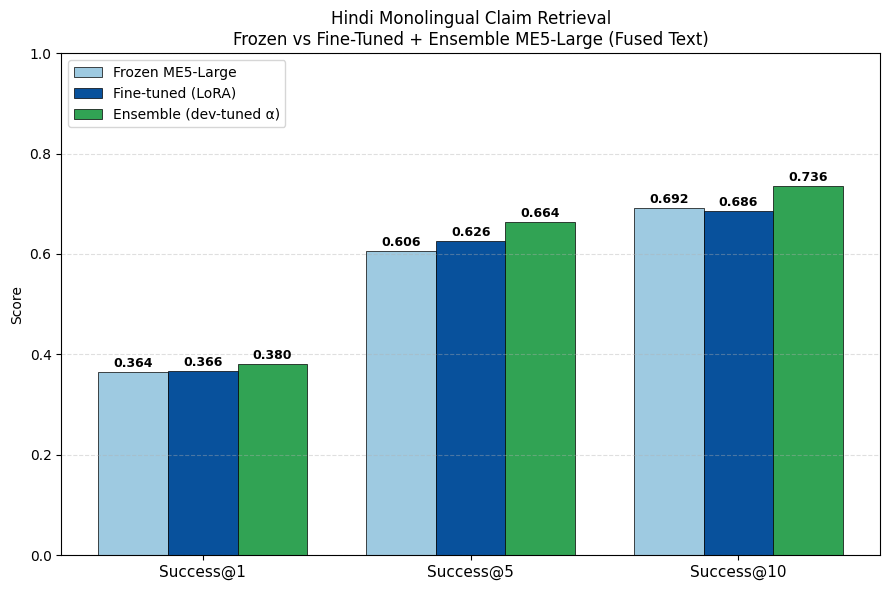

Saved chart to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_comparison_hin/frozen_vs_finetuned_chart_hin.png


In [23]:
# ============================================================
# CELL 41: COMPARISON CHART — GROUPED BAR (Hindi)
# ============================================================
import matplotlib.pyplot as plt

metrics = ['success@1', 'success@5', 'success@10']
fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(3)
width = 0.26

frozen_vals = [hin_results_frozen[m] for m in metrics]
finetuned_vals = [hin_results_finetuned[m] for m in metrics]
ensemble_vals = [hin_results_ensemble[m] for m in metrics]

bars1 = ax.bar(x - width, frozen_vals, width, label='Frozen ME5-Large', color='#9ECAE1', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, finetuned_vals, width, label='Fine-tuned (LoRA)', color='#08519C', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, ensemble_vals, width, label='Ensemble (dev-tuned α)', color='#31A354', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['Success@1', 'Success@5', 'Success@10'], fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.set_title('Hindi Monolingual Claim Retrieval\nFrozen vs Fine-Tuned + Ensemble ME5-Large (Fused Text)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
chart_path = os.path.join(hin_results_output_dir, 'frozen_vs_finetuned_chart_hin.png')
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {chart_path}')

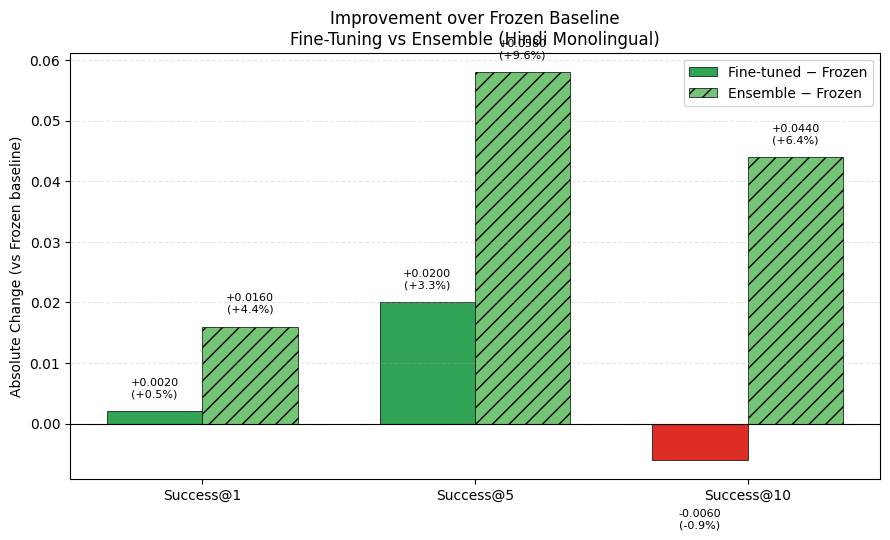

Saved chart to: /content/drive/MyDrive/semeval_hin_mono4sep_results/final_comparison_hin/improvement_delta_chart_hin.png


In [24]:
# ============================================================
# CELL 42: IMPROVEMENT DELTA CHART — Hindi
# ============================================================
metrics_labels = ['Success@1', 'Success@5', 'Success@10']
ft_deltas = [hin_improvement[m] for m in metrics]
ft_pct = [hin_pct_improvement[m] for m in metrics]

hin_ens_improvement = {m: hin_results_ensemble[m] - hin_results_frozen[m] for m in metrics}
hin_ens_pct = {m: (hin_ens_improvement[m] / hin_results_frozen[m]) * 100 for m in metrics}
ens_deltas = [hin_ens_improvement[m] for m in metrics]

fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(3)
width = 0.35

bars_ft = ax.bar(x - width/2, ft_deltas, width, label='Fine-tuned − Frozen',
                  color=['#31A354' if d >= 0 else '#DE2D26' for d in ft_deltas],
                  edgecolor='black', linewidth=0.5)
bars_ens = ax.bar(x + width/2, ens_deltas, width, label='Ensemble − Frozen',
                   color=['#74C476' if d >= 0 else '#FC9272' for d in ens_deltas],
                   edgecolor='black', linewidth=0.5, hatch='//')

for bars, vals, pcts in [(bars_ft, ft_deltas, ft_pct), (bars_ens, ens_deltas, [hin_ens_pct[m] for m in metrics])]:
    for bar, val, pct in zip(bars, vals, pcts):
        y_pos = val + 0.002 if val >= 0 else val - 0.008
        ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.4f}\n({pct:+.1f}%)',
                ha='center', va='bottom' if val >= 0 else 'top', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Absolute Change (vs Frozen baseline)')
ax.set_title('Improvement over Frozen Baseline\nFine-Tuning vs Ensemble (Hindi Monolingual)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
delta_chart_path = os.path.join(hin_results_output_dir, 'improvement_delta_chart_hin.png')
plt.savefig(delta_chart_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved chart to: {delta_chart_path}')

In [25]:
# ============================================================
# HIN CELL A: HEADROOM CHECK — is top-10 leaving points on the table
# vs top-50? (identical logic to eng-eng Cell 14)
# ============================================================
combo_dev_hin = hin_best_alpha * hin_sims_ft_dev + (1 - hin_best_alpha) * hin_sims_fr_dev
topk50_idx_hin = torch.topk(combo_dev_hin, k=50, dim=1).indices
hin_dev_ranked_top50 = {str(pid): [str(hin_claim_ids[j]) for j in topk50_idx_hin[i].tolist()]
                         for i, pid in enumerate(hin_dev_post_ids_list)}

hin_dev_s10 = success_at_k(hin_dev_ranked_top50, hin_dev_truth, 10)
hin_dev_s50 = success_at_k(hin_dev_ranked_top50, hin_dev_truth, 50)
print(f'DEV success@10: {hin_dev_s10:.4f}   DEV success@50: {hin_dev_s50:.4f}   Headroom: {hin_dev_s50-hin_dev_s10:+.4f}')
print('✅ Headroom exists' if hin_dev_s50 - hin_dev_s10 >= 0.02 else '⚠️ Little headroom — proceed cautiously')

DEV success@10: 0.7406   DEV success@50: 0.8473   Headroom: +0.1067
✅ Headroom exists


In [26]:
# ============================================================
# HIN CELL B: BUILD TOP-50 STAGE-1 CANDIDATES (dev + test)
# ============================================================
def build_stage1_candidates_biencoder_only(post_ids, ensemble_topk_idx, claim_id_list):
    return {
        str(pid): [str(claim_id_list[j]) for j in ensemble_topk_idx[i].tolist()]
        for i, pid in enumerate(post_ids)
    }

hin_dev_candidates = build_stage1_candidates_biencoder_only(hin_dev_post_ids_list, topk50_idx_hin, hin_claim_ids)

hin_test_topk50_idx = torch.topk(hin_combo_test, k=50, dim=1).indices
hin_test_candidates = build_stage1_candidates_biencoder_only(hin_test_post_ids_list, hin_test_topk50_idx, hin_test_claim_ids)

print(f'DEV candidates built for {len(hin_dev_candidates)} posts, top-50 each')
print(f'DEV recall@50: {success_at_k(hin_dev_candidates, hin_dev_truth, 50):.4f}')

DEV candidates built for 478 posts, top-50 each
DEV recall@50: 0.8473


In [27]:
# ============================================================
# HIN CELL C: FREE THE BI-ENCODERS — reranker needs the GPU headroom
# ============================================================
del eval_model, eval_base_model, frozen_model
gc.collect()
torch.cuda.empty_cache()
print(f'GPU allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB')

GPU allocated: 0.01 GB


In [28]:
# ============================================================
# HIN CELL D: LOAD CROSS-ENCODER — bge-reranker-v2-m3 is multilingual,
# works on Hindi text unchanged. No model swap needed.
# ============================================================
from sentence_transformers import CrossEncoder

torch.cuda.empty_cache()
try:
    reranker = CrossEncoder(
        'BAAI/bge-reranker-v2-m3',
        max_length=256,
        device=device,
        automodel_args={'torch_dtype': torch.float16},
    )
    print('Reranker loaded on GPU (fp16).')
except torch.cuda.OutOfMemoryError:
    print('OOM on GPU — falling back to CPU.')
    reranker = CrossEncoder('BAAI/bge-reranker-v2-m3', max_length=256, device='cpu')

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

Reranker loaded on GPU (fp16).


In [29]:
# ============================================================
# HIN CELL E: RERANK PIPELINE (identical function, language-agnostic)
# ============================================================
def rerank_pipeline(post_ids, post_texts, candidates_dict, claim_text_lookup, beta=0.5, top_k=10):
    final_ranked = {}
    for pid, post_text in zip(post_ids, post_texts):
        cand_ids = candidates_dict[str(pid)]
        valid_ids = [cid for cid in cand_ids if cid in claim_text_lookup]
        if not valid_ids:
            final_ranked[str(pid)] = cand_ids[:top_k]
            continue
        pairs = [(post_text, claim_text_lookup[cid]) for cid in valid_ids]
        ce_scores = np.array(reranker.predict(pairs, batch_size=32, show_progress_bar=False))
        ce_norm = (ce_scores - ce_scores.min()) / (ce_scores.max() - ce_scores.min() + 1e-9)
        retriever_score = np.linspace(1.0, 0.0, num=len(valid_ids))
        fused = beta * ce_norm + (1 - beta) * retriever_score
        order = np.argsort(-fused)
        final_ranked[str(pid)] = [valid_ids[i] for i in order[:top_k]]
    return final_ranked

In [30]:
# ============================================================
# HIN CELL F1: TRAIN THE RERANKER, SAVE IMMEDIATELY TO DRIVE
# Run this once. If it succeeds, you never need to re-run it —
# Cell F2 below will just reload from disk.
# ============================================================
from sentence_transformers import CrossEncoder, InputExample
from torch.utils.data import DataLoader
import random

random.seed(42)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

HIN_RERANKER_SAVE_PATH = os.path.join(OUTPUT_DIR, 'reranker_finetuned_hin_v1')

if os.path.exists(HIN_RERANKER_SAVE_PATH):
    print(f'✅ Found already-trained reranker at {HIN_RERANKER_SAVE_PATH} — skip to Cell F2, no need to retrain.')
else:
    if 'reranker' in globals():
        del reranker
    gc.collect(); torch.cuda.empty_cache()
    print(f'GPU reserved before CE training: {torch.cuda.memory_reserved()/1e9:.2f} GB')

    hin_claim_id_to_text_str = {str(k): v for k, v in hin_claim_id_to_text.items()}
    hin_post_id_to_text_str  = {str(k): v for k, v in hin_post_id_to_text.items()}

    N_NEG_PER_POS = 4
    hin_train_examples = []
    all_hin_claim_ids_set = set(hin_claim_id_to_text_str.keys())
    hin_grouped = hin_usable_train_pairs.groupby('post_id')['fact_check_id'].apply(list).to_dict()

    for pid, true_fcs in hin_grouped.items():
        pid_str = str(pid)
        if pid_str not in hin_post_id_to_text_str:
            continue
        post_text = hin_post_id_to_text_str[pid_str]
        true_fcs_str = [str(fc) for fc in true_fcs]
        for fc in true_fcs_str:
            if fc not in hin_claim_id_to_text_str:
                continue
            hin_train_examples.append(InputExample(texts=[post_text, hin_claim_id_to_text_str[fc]], label=1.0))
            neg_pool = list(all_hin_claim_ids_set - set(true_fcs_str))
            for neg in random.sample(neg_pool, min(N_NEG_PER_POS, len(neg_pool))):
                hin_train_examples.append(InputExample(texts=[post_text, hin_claim_id_to_text_str[neg]], label=0.0))

    random.shuffle(hin_train_examples)
    print(f'Built {len(hin_train_examples)} Hindi CE training examples')

    hin_train_dataloader = DataLoader(hin_train_examples, shuffle=True, batch_size=4)

    hin_reranker_ft = CrossEncoder(
        'BAAI/bge-reranker-v2-m3',
        max_length=256,
        device=device,
        automodel_args={'torch_dtype': torch.float32},
    )

    hin_reranker_ft.fit(
        train_dataloader=hin_train_dataloader,
        epochs=1,
        warmup_steps=int(0.1 * len(hin_train_dataloader)),
        optimizer_params={'lr': 2e-5},
        use_amp=True,
        show_progress_bar=True,
    )

    # ---- SAVE IMMEDIATELY — this is the step that was missing before ----
    hin_reranker_ft.save(HIN_RERANKER_SAVE_PATH)
    print(f'💾 Saved fine-tuned reranker to: {HIN_RERANKER_SAVE_PATH}')

    reranker = hin_reranker_ft
    print('Fine-tuned Hindi reranker trained, saved, and ready.')

GPU reserved before CE training: 0.02 GB
Built 27230 Hindi CE training examples


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Step,Training Loss
500,0.276618
1000,0.204333
1500,0.154880
2000,0.173523
2500,0.160864
3000,0.165657
3500,0.131701
4000,0.118436
4500,0.103409
5000,0.126711


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Saved fine-tuned reranker to: /content/drive/MyDrive/semeval_hin_mono4sep_results/reranker_finetuned_hin_v1
Fine-tuned Hindi reranker trained, saved, and ready.


In [31]:
# ============================================================
# HIN CELL F2: LOAD TRAINED RERANKER (from disk if F1 already ran in
# a prior session), SWEEP BETA ON DEV, APPLY TO TEST
# ============================================================
HIN_RERANKER_SAVE_PATH = os.path.join(OUTPUT_DIR, 'reranker_finetuned_hin_v1')

if 'reranker' not in globals() or not isinstance(reranker, CrossEncoder):
    from sentence_transformers import CrossEncoder
    reranker = CrossEncoder(HIN_RERANKER_SAVE_PATH, max_length=256, device=device)
    print(f'✅ Loaded fine-tuned reranker from disk: {HIN_RERANKER_SAVE_PATH}')

hin_claim_id_to_text_str = {str(k): v for k, v in hin_claim_id_to_text.items()}
hin_test_claim_id_to_text_str = {str(k): v for k, v in hin_test_claim_id_to_text.items()}

hin_best_beta, hin_best_beta_score = 0.5, -1
for beta in np.arange(0.0, 1.01, 0.1):
    ranked = rerank_pipeline(hin_dev_post_ids_list, hin_dev_post_texts_list, hin_dev_candidates,
                              hin_claim_id_to_text_str, beta=beta)
    score = success_at_k(ranked, hin_dev_truth, 10)
    print(f'beta={beta:.1f}  dev success@10={score:.4f}')
    if score > hin_best_beta_score:
        hin_best_beta_score, hin_best_beta = score, beta
print(f'\nBest beta on Hindi DEV: {hin_best_beta:.2f}  (success@10={hin_best_beta_score:.4f})')

FINAL_BETA_HIN = hin_best_beta
hin_test_reranked_ft = rerank_pipeline(hin_test_post_ids_list, hin_test_post_texts_list, hin_test_candidates,
                                        hin_test_claim_id_to_text_str, beta=FINAL_BETA_HIN)

print('\n=== HIN TEST: ensemble baseline (no rerank) ===')
_ = evaluate_all_k(hin_retrieved_ranked_ensemble, hin_test_reference)

print(f'\n=== HIN TEST: ensemble + fine-tuned cross-encoder rerank (beta={FINAL_BETA_HIN:.2f}) ===')
hin_results_reranked_ft = evaluate_all_k(hin_test_reranked_ft, hin_test_reference)

beta=0.0  dev success@10=0.7406
beta=0.1  dev success@10=0.7427
beta=0.2  dev success@10=0.7510
beta=0.3  dev success@10=0.7552
beta=0.4  dev success@10=0.7531
beta=0.5  dev success@10=0.7552
beta=0.6  dev success@10=0.7552
beta=0.7  dev success@10=0.7552
beta=0.8  dev success@10=0.7552
beta=0.9  dev success@10=0.7552
beta=1.0  dev success@10=0.7866

Best beta on Hindi DEV: 1.00  (success@10=0.7866)

=== HIN TEST: ensemble baseline (no rerank) ===
success@1: 0.3800
success@5: 0.6640
success@10: 0.7360

=== HIN TEST: ensemble + fine-tuned cross-encoder rerank (beta=1.00) ===
success@1: 0.3980
success@5: 0.6700
success@10: 0.7380


In [32]:
# ============================================================
# HIN CELL G: SAVE FINAL COMPARISON — adds the rerank row to your table
# ============================================================
hin_out_dir = os.path.join(OUTPUT_DIR, 'reranking_pipeline_results_CE_FINETUNED_hin')
os.makedirs(hin_out_dir, exist_ok=True)

hin_comparison = pd.DataFrame({
    'Frozen ME5-Large (Hindi)': hin_results_frozen,
    'Fine-tuned ME5-Large + LoRA (Hindi)': hin_results_finetuned,
    'Ensemble (dev-tuned alpha)': hin_results_ensemble,
    'Ensemble + CE Rerank (fine-tuned)': hin_results_reranked_ft,
}).T[['success@1', 'success@5', 'success@10']]

print(hin_comparison.round(4).to_string())

hin_comparison.to_csv(os.path.join(hin_out_dir, 'comparison_ce_finetuned_hin.csv'))
with open(os.path.join(hin_out_dir, 'predictions_ce_finetuned_test_hin.json'), 'w') as f:
    json.dump(hin_test_reranked_ft, f, indent=2)

# Also save the beta value used, for reproducibility
with open(os.path.join(hin_out_dir, 'best_beta_hin.json'), 'w') as f:
    json.dump({'best_beta': float(FINAL_BETA_HIN), 'dev_success_at_10': float(hin_best_beta_score)}, f, indent=2)

print(f'\n💾 Saved to: {hin_out_dir}')

                                     success@1  success@5  success@10
Frozen ME5-Large (Hindi)                 0.364      0.606       0.692
Fine-tuned ME5-Large + LoRA (Hindi)      0.366      0.626       0.686
Ensemble (dev-tuned alpha)               0.380      0.664       0.736
Ensemble + CE Rerank (fine-tuned)        0.398      0.670       0.738

💾 Saved to: /content/drive/MyDrive/semeval_hin_mono4sep_results/reranking_pipeline_results_CE_FINETUNED_hin


In [33]:
# ============================================================
# HIN CELL H: STABILITY CHECK — how much did reranking actually move
# things vs the ensemble baseline?
# ============================================================
n_top1_changed = 0
n_top10_set_changed = 0
all_ce_stds = []

for pid in hin_test_post_ids_list[:200]:
    pid_str = str(pid)
    baseline_top10 = set(hin_retrieved_ranked_ensemble.get(pid_str, []))
    reranked_top10 = set(hin_test_reranked_ft.get(pid_str, []))

    baseline_top1 = hin_retrieved_ranked_ensemble.get(pid_str, [None])[0]
    reranked_top1 = hin_test_reranked_ft.get(pid_str, [None])[0]

    if baseline_top1 != reranked_top1:
        n_top1_changed += 1
    if baseline_top10 != reranked_top10:
        n_top10_set_changed += 1

    cand_ids = hin_test_candidates[pid_str]
    valid_ids = [c for c in cand_ids if c in hin_test_claim_id_to_text_str]
    post_text = hin_test_post_id_to_text[pid]
    if valid_ids:
        pairs = [(post_text, hin_test_claim_id_to_text_str[c]) for c in valid_ids]
        scores = reranker.predict(pairs, show_progress_bar=False)
        all_ce_stds.append(np.std(scores))

print(f'Posts where TOP-1 changed        : {n_top1_changed} / 200')
print(f'Posts where TOP-10 SET changed    : {n_top10_set_changed} / 200')
print(f'Mean CE score std across posts    : {np.mean(all_ce_stds):.6f}')

Posts where TOP-1 changed        : 100 / 200
Posts where TOP-10 SET changed    : 200 / 200
Mean CE score std across posts    : 0.377876
